In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
merged=pd.read_csv("../Processed/merged.csv")

In [14]:
latest_season = merged['season'].max()
last_3_seasons = [latest_season - 2, latest_season - 1, latest_season]

df3 = merged[merged['season'].isin(last_3_seasons)]



In [15]:
retained_players = {
    # CSK
    'RD Gaikwad',
    'M Pathirana',
    'S Dube',
    'RA Jadeja',
    'MS Dhoni',

    # DC
    'AR Patel',
    'Kuldeep Yadav',
    'T Stubbs',
    'Abishek Porel',

    # GT
    'Rashid Khan',
    'Shubman Gill',
    'B Sai Sudharsan',
    'R Tewatia',
    'M Shahrukh Khan',

    # KKR
    'RK Singh',
    'CV Varun',
    'SP Narine',
    'AD Russell',
    'Harshit Rana',
    'Ramandeep Singh',

    # LSG
    'N Pooran',
    'Ravi Bishnoi',
    'Mayank Yadav',
    'Mohsin Khan',
    'A Badoni',

    # MI
    'JJ Bumrah',
    'SA Yadav',
    'HH Pandya',
    'RG Sharma',
    'Tilak Varma',

    # PBKS
    'Shashank Singh',
    'P Simran Singh',

    # RR
    'SV Samson',
    'YBK Jaiswal',
    'R Parag',
    'Dhruv Jurel',
    'SO Hetmyer',
    'Sandeep Sharma',

    # RCB
    'V Kohli',
    'RM Patidar',
    'Yash Dayal',
   
    # SRH
    'PJ Cummins',
    'Abhishek Sharma',
    'Nithish Kumar Reddy',
    'H Klaasen',
    'TM Head'
}


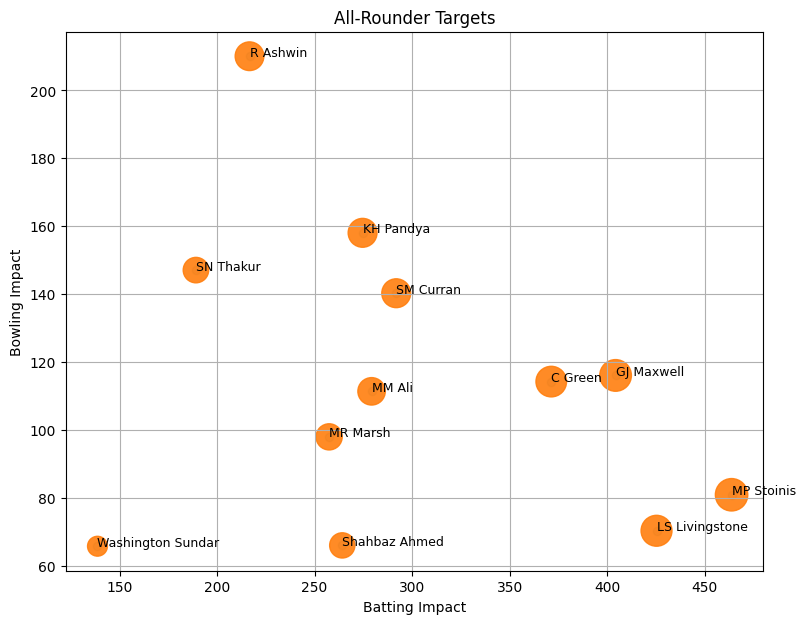

,runs,sr,wickets,econ,allround_score
player,,,,,
MP Stoinis,938,147.72,14,9.64,544.68
GJ Maxwell,753,171.92,18,7.75,520.36
LS Livingstone,811,168.26,11,9.10,495.59
C Green,699,152.95,20,9.23,485.57
KH Pandya,504,121.74,26,7.50,432.68
SM Curran,537,128.47,27,10.35,432.12
R Ashwin,343,132.43,37,7.87,426.74
MM Ali,494,136.09,17,7.71,390.58
MR Marsh,440,135.80,17,9.39,355.39


<Figure size 640x480 with 0 Axes>

In [17]:
df_bat_auction = df3[~df3['batter'].isin(retained_players)].copy()
df_bowl_auction = df3[~df3['bowler'].isin(retained_players)].copy()

legal_balls = df_bat_auction[~df_bat_auction['extras_type'].isin(['wides','noballs'])]

bat = (
    legal_balls
    .groupby('batter')
    .agg(
        runs=('batsman_runs','sum'),
        balls=('ball','count')
    )
)

bat['sr'] = bat['runs'] / bat['balls'] * 100
bat.index.name = 'player'

legal_bowl = df_bowl_auction[~df_bowl_auction['extras_type'].isin(['wides','noballs'])]

bowl_balls = legal_bowl.groupby('bowler').agg(balls_bowled=('ball','count'))
bowl_runs_wkts = df_bowl_auction.groupby('bowler').agg(
    wickets=('is_wicket','sum'),
    runs_conceded=('total_runs','sum')
)

bowl = bowl_runs_wkts.merge(bowl_balls, left_index=True, right_index=True)
bowl['econ'] = bowl['runs_conceded'] / (bowl['balls_bowled'] / 6)
bowl.index.name = 'player'

all_round = bat.merge(bowl, on='player', how='inner')

all_round = all_round[
    (all_round['runs'] >= 150) &
    (all_round['balls'] >= 50) &
    (all_round['wickets'] >= 10) &
    (all_round['econ'] <= 11)
]

all_round['bat_score'] = all_round['runs'] * 0.4 + all_round['sr'] * 0.6
all_round['bowl_score'] = all_round['wickets'] * 5 + (11 - all_round['econ']) * 8
all_round['allround_score'] = all_round['bat_score'] + all_round['bowl_score']

top_allrounders = all_round.sort_values('allround_score', ascending=False).head(15)

plt.figure(figsize=(9,7))

plt.scatter(all_round['bat_score'], all_round['bowl_score'], alpha=0.3)

plt.scatter(
    top_allrounders['bat_score'],
    top_allrounders['bowl_score'],
    s=top_allrounders['allround_score'],
    alpha=0.9
)

for player in top_allrounders.index:
    plt.text(
        top_allrounders.loc[player,'bat_score'],
        top_allrounders.loc[player,'bowl_score'],
        player,
        fontsize=9
    )

plt.xlabel("Batting Impact")
plt.ylabel("Bowling Impact")
plt.title("All-Rounder Targets")
plt.grid(True)
plt.show()
plt.savefig('../Images/All-Rounder Targets.png', dpi=150, bbox_inches='tight')
top_allrounders[['runs','sr','wickets','econ','allround_score']].round(2)


1) Glenn Maxwell:-
Elite strike rate + solid wickets + excellent economy. Match-winner who gives impact in both innings, not just filler overs.

2) Marcus Stoinis:-
Highest overall output, reliable top-order hitting, can bowl tough overs. Safe, proven, plug-and-play all-rounder.

3) Cameron Green:-
Rare combo: big runs + 20 wickets at under-control economy. Long-term asset, gives balance and matchup flexibility.

4) Sam Curran:-
27 wickets is the real story. Batting is secondary but serviceable. Wins games late with ball.

5) Ravichandran Ashwin:-
Helps for control and wickets in middle overs with spin, he’s gold. Batting is a bonus.

6) Krunal Pandya:-
Low strike rate but very economical and consistent wickets. Utility player.

In [ ]:
keepers = df3[df3['dismissal_kind'] == 'stumped']['fielder'].unique()

df_field = df3[
    (~df3['fielder'].isin(retained_players)) &
    (~df3['fielder'].isin(keepers)) &
    (df3['fielder'].notna())
].copy()

catches = df_field[df_field['dismissal_kind'] == 'caught'] \
    .groupby('fielder').size()

runouts = df_field[df_field['dismissal_kind'] == 'run out'] \
    .groupby('fielder').size()

field = pd.concat([catches, runouts], axis=1).fillna(0)
field.columns = ['catches', 'runouts']

field['total_events'] = field['catches'] + field['runouts']

field = field[field['total_events'] >= 8]

field['field_score'] = field['catches'] * 2 + field['runouts'] * 3

top_fielders = field.sort_values('field_score', ascending=False).head(20)

top_fielders[['catches','runouts','field_score']]


,catches,runouts,field_score
fielder,,,
JC Buttler,21.0,3.0,51.0
DA Miller,22.0,2.0,50.0
DJ Hooda,22.0,1.0,47.0
TH David,22.0,1.0,47.0
PD Salt,17.0,3.0,43.0
SS Iyer,15.0,4.0,42.0
AK Markram,21.0,0.0,42.0
KH Pandya,18.0,1.0,39.0
MA Agarwal,18.0,1.0,39.0


In [ ]:
set(keepers)

{'H Klaasen',
 'Ishan Kishan',
 'JM Sharma',
 'KD Karthik',
 'KL Rahul',
 'MS Dhoni',
 'MS Wade',
 'N Pooran',
 'Q de Kock',
 'RR Pant',
 'SP Jackson',
 'SV Samson',
 'SW Billings',
 'WP Saha'}